In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

pa_gs = pd.read_csv('data/pa_data.csv').dropna()
coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]

In [2]:
X = pa_gs[['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'ohc700_atlantic', 'ohc700_atlantic_se', 
    'ohc700_north_atlantic', 'ohc700_north_atlantic_se', 'ohc700_south_atlantic', 'ohc700_south_atlantic_se', 
    'ohc2000_north_atlantic', 'ohc700_pacific', 'ohc700_world','ohc700_natl_djf', 'ohc700_natl_amj', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']]
y = pa_gs['growing_season_length']

In [36]:
def principal_component_analysis(X, y):
    #creates and graphs principal component analysis for inputted X and y
    #required libraries: from sklearn.preprocessing import StandardScalar, from sklearn.decomposition import PCA,
    #from sklearn.linear_model import LinearRegression, matplotlib.pyplot as plt, numpy as np, seaborn as sns

    #gets list of columns in input X for future conversion of X_train back into dataframe
    columns_X = list(X.columns)

    # splits data into X_train, X_test, y_train, and y_test and makes X_train a dataframe
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_train = pd.DataFrame(X_train, columns = columns_X)

    # First PCA
    pca1 = PCA()
    X_pca1 = pca1.fit_transform(X_train)
    plt.bar(range(1,len(pca1.explained_variance_)+1),pca1.explained_variance_)
    plt.ylabel('Explained Variance')
    plt.xlabel('Components')
    plt.plot(range(1,len(pca1.explained_variance_)+1), np.cumsum(pca1.explained_variance_), 
         c='red', label = 'Cumulative Explained Variance')
    plt.legend(loc='upper left')
    plt.show()

    # Second PCA
    pca2b = PCA(n_components=2)
    X_pca2b = pca2b.fit_transform(X_train)
    colormap = plt.get_cmap('coolwarm')
    plt.figure()
    scatter = plt.scatter(X_pca2b[:, 0], X_pca2b[:, 1], c=y_train, cmap= colormap)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label = 'Growing Season Length')
    plt.show()

    # Third PCA
    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(X_train)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=y_train, cmap=colormap)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.show()

    loadings = pca3.components_.T * np.sqrt(pca3.explained_variance_)
    plt.figure(figsize=(10, 8))
    sns.heatmap(loadings, annot=True, cmap='coolwarm', xticklabels=['PC1', 'PC2', 'PC3'], yticklabels=X.columns)
    plt.title('Feature Importance in Principal Components')
    plt.show()

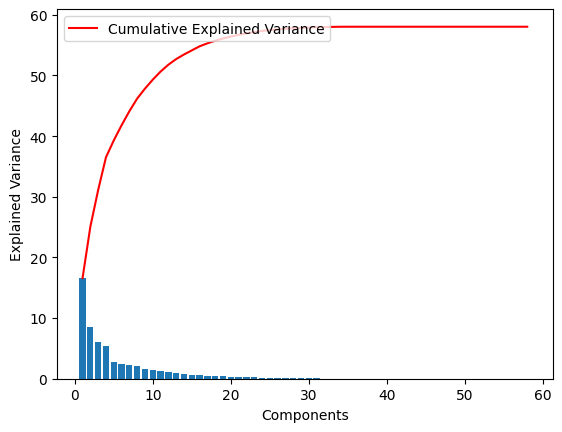

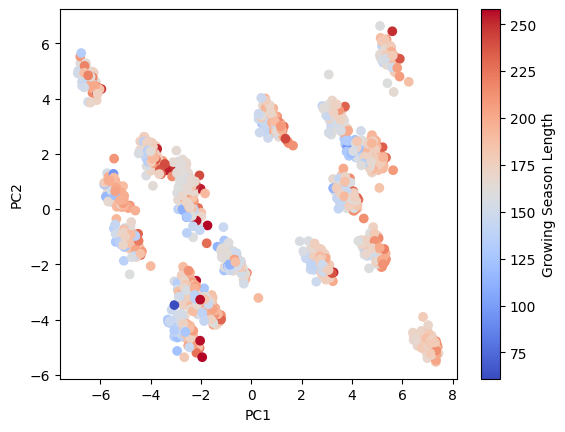

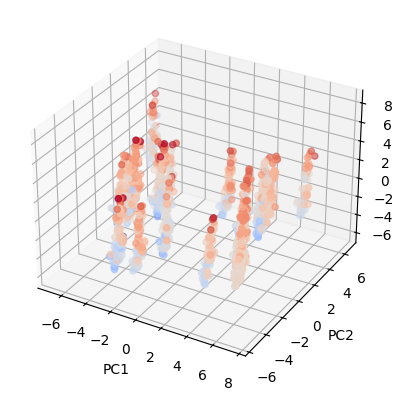

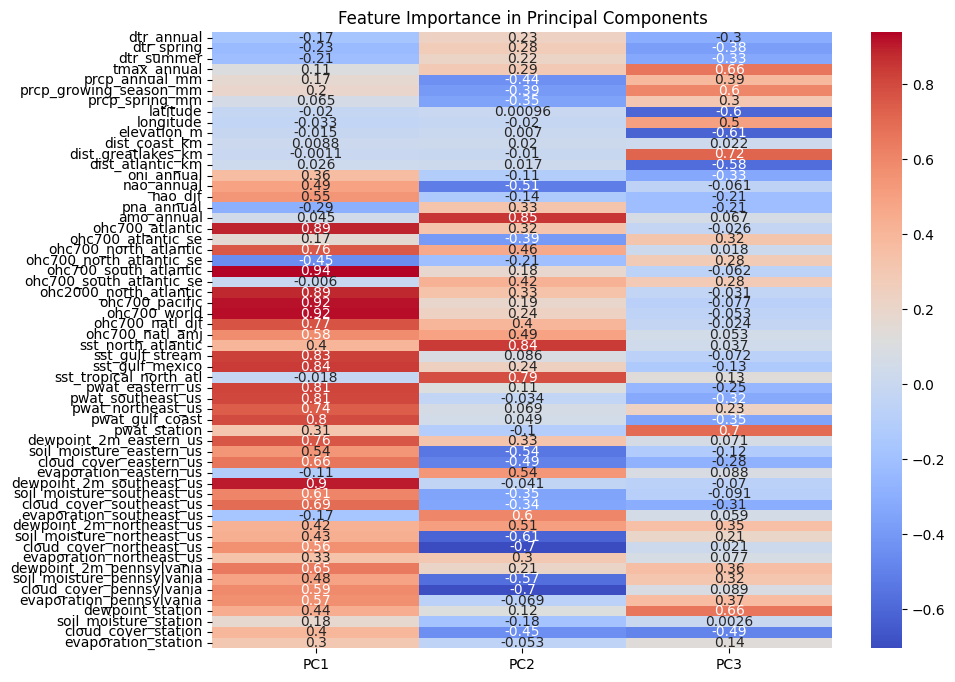

In [37]:
principal_component_analysis(X, y)

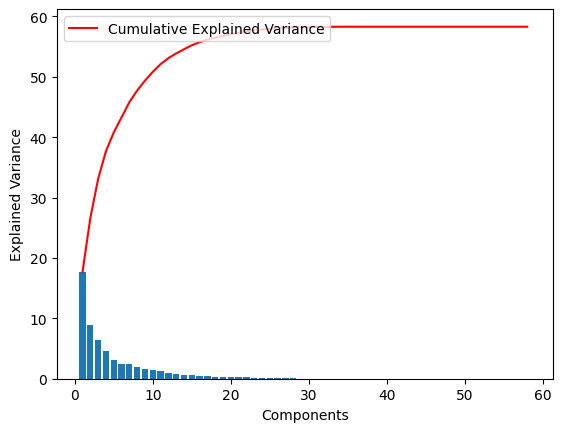

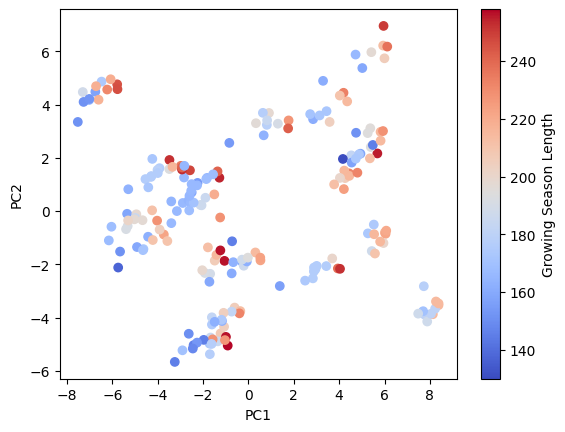

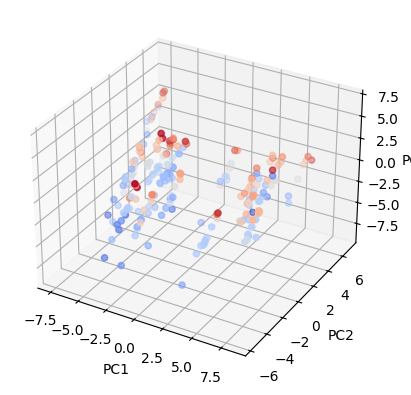

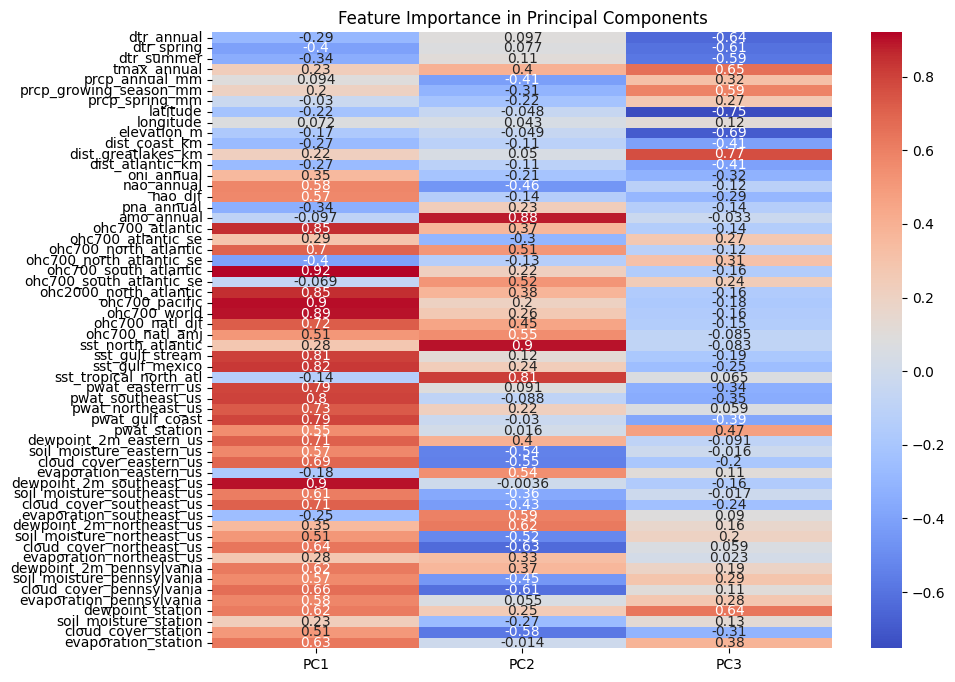

In [38]:
X_coastal = coastal_pa_stations[['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'ohc700_atlantic', 'ohc700_atlantic_se', 
    'ohc700_north_atlantic', 'ohc700_north_atlantic_se', 'ohc700_south_atlantic', 'ohc700_south_atlantic_se', 
    'ohc2000_north_atlantic', 'ohc700_pacific', 'ohc700_world','ohc700_natl_djf', 'ohc700_natl_amj', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']]
y_coastal = coastal_pa_stations['growing_season_length']
principal_component_analysis(X_coastal, y_coastal)

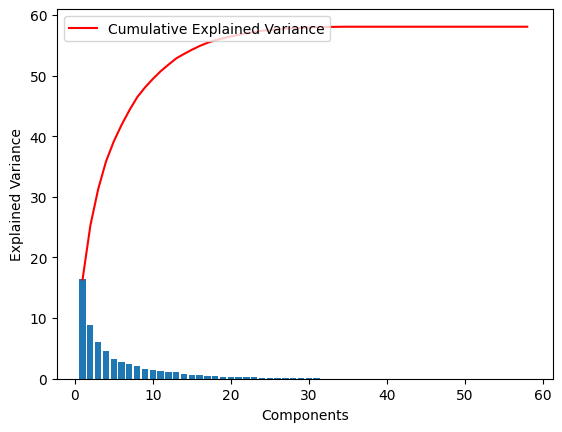

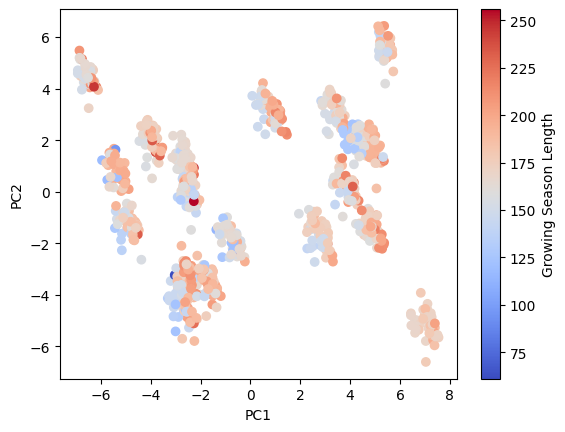

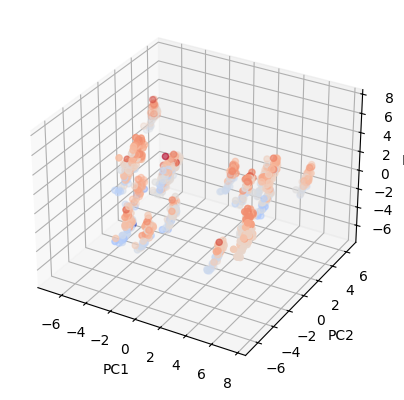

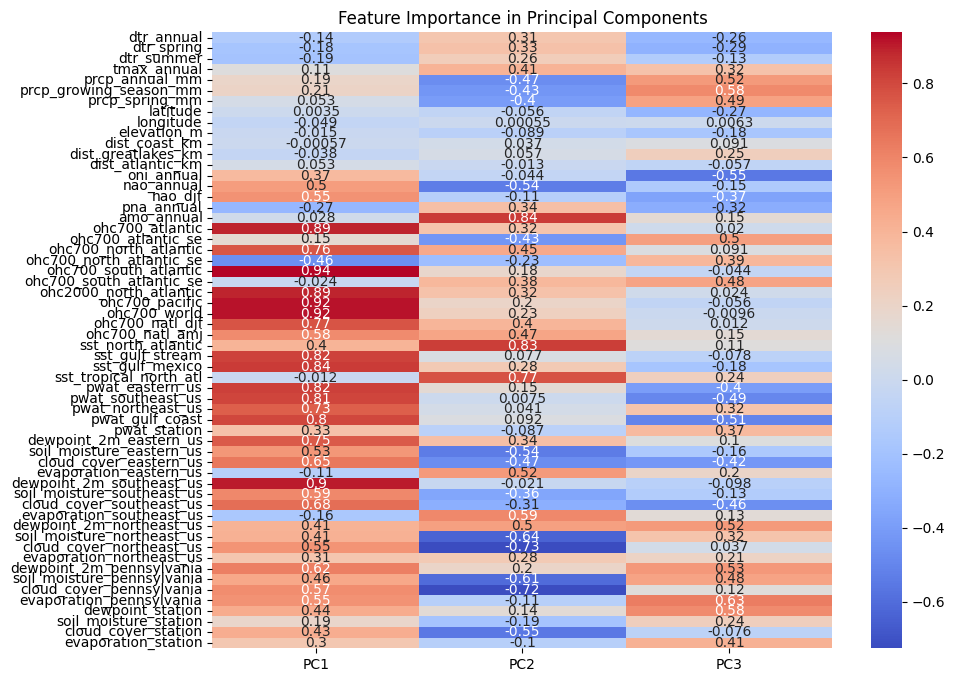

In [39]:
X_inland = inland_pa_stations[['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'ohc700_atlantic', 'ohc700_atlantic_se', 
    'ohc700_north_atlantic', 'ohc700_north_atlantic_se', 'ohc700_south_atlantic', 'ohc700_south_atlantic_se', 
    'ohc2000_north_atlantic', 'ohc700_pacific', 'ohc700_world','ohc700_natl_djf', 'ohc700_natl_amj', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']]
y_inland = inland_pa_stations['growing_season_length']
principal_component_analysis(X_inland, y_inland)

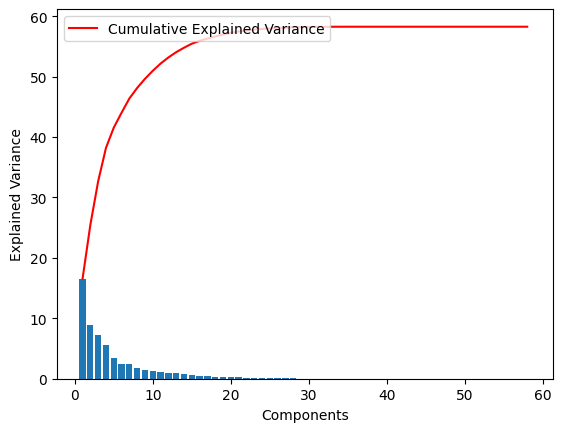

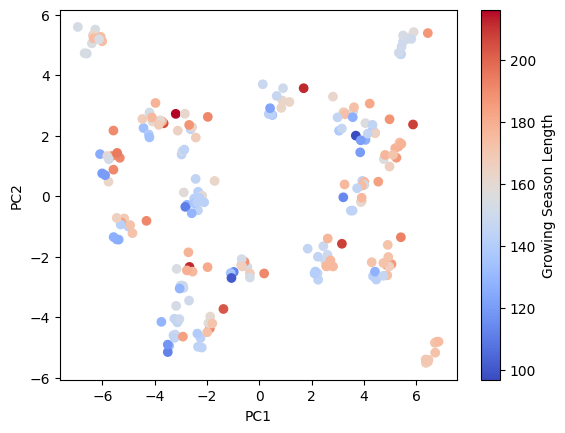

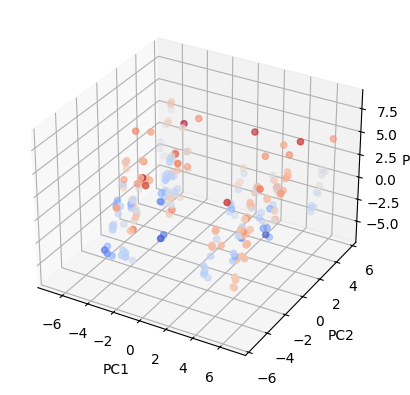

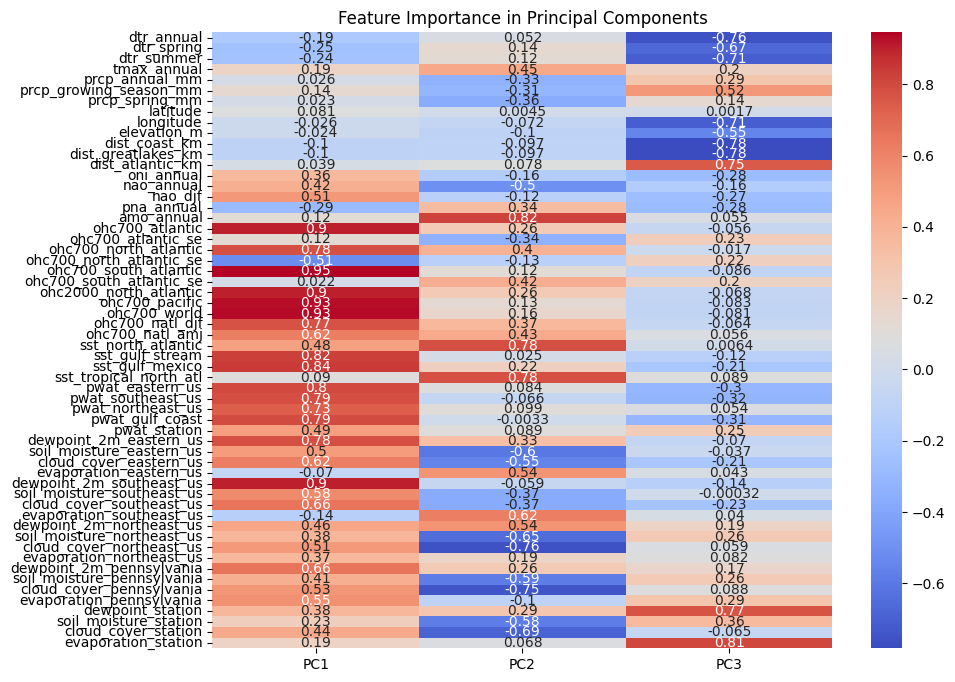

In [40]:
X_lakeside = lakeside_pa_stations[['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'ohc700_atlantic', 'ohc700_atlantic_se', 
    'ohc700_north_atlantic', 'ohc700_north_atlantic_se', 'ohc700_south_atlantic', 'ohc700_south_atlantic_se', 
    'ohc2000_north_atlantic', 'ohc700_pacific', 'ohc700_world','ohc700_natl_djf', 'ohc700_natl_amj', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']]
y_lakeside = lakeside_pa_stations['growing_season_length']
principal_component_analysis(X_lakeside, y_lakeside)